# ==============================================================================
# Imports
# ==============================================================================


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import pefile
import requests
import tkinter as tk
from tkinter import filedialog, messagebox

# Supervised & Unsupervised Metrics


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, roc_curve, roc_auc_score,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)

print("Libraries imported successfully!")


Libraries imported successfully!


# ==============================================================================
# Data Loading and EDA
# ==============================================================================


In [3]:
try:
    df = pd.read_csv('data_file.csv')
    print(f"Dataset loaded! Shape: {df.shape}")
except FileNotFoundError:
    print("Error: 'data_file.csv' not found. Please ensure it's in the correct directory.")

Dataset loaded! Shape: (62485, 18)


## Class Distribution Analysis

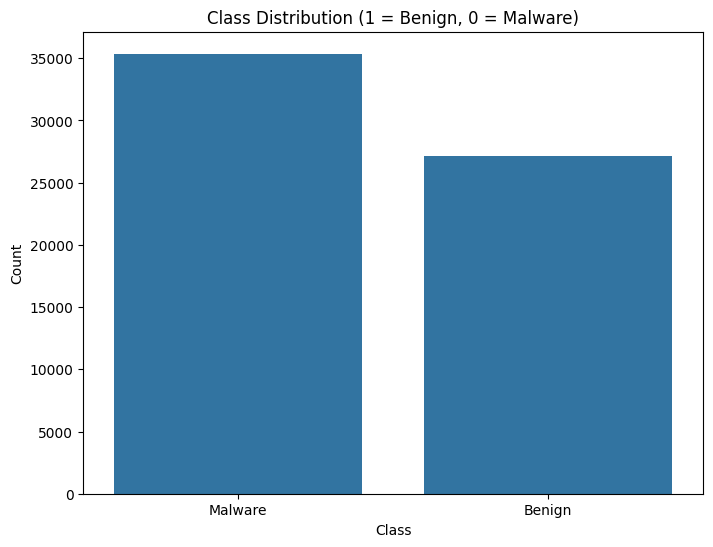

In [4]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Benign', data=df)
plt.title('Class Distribution (1 = Benign, 0 = Malware)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Malware', 'Benign'])
plt.show()

## Feature Correlation Analysis


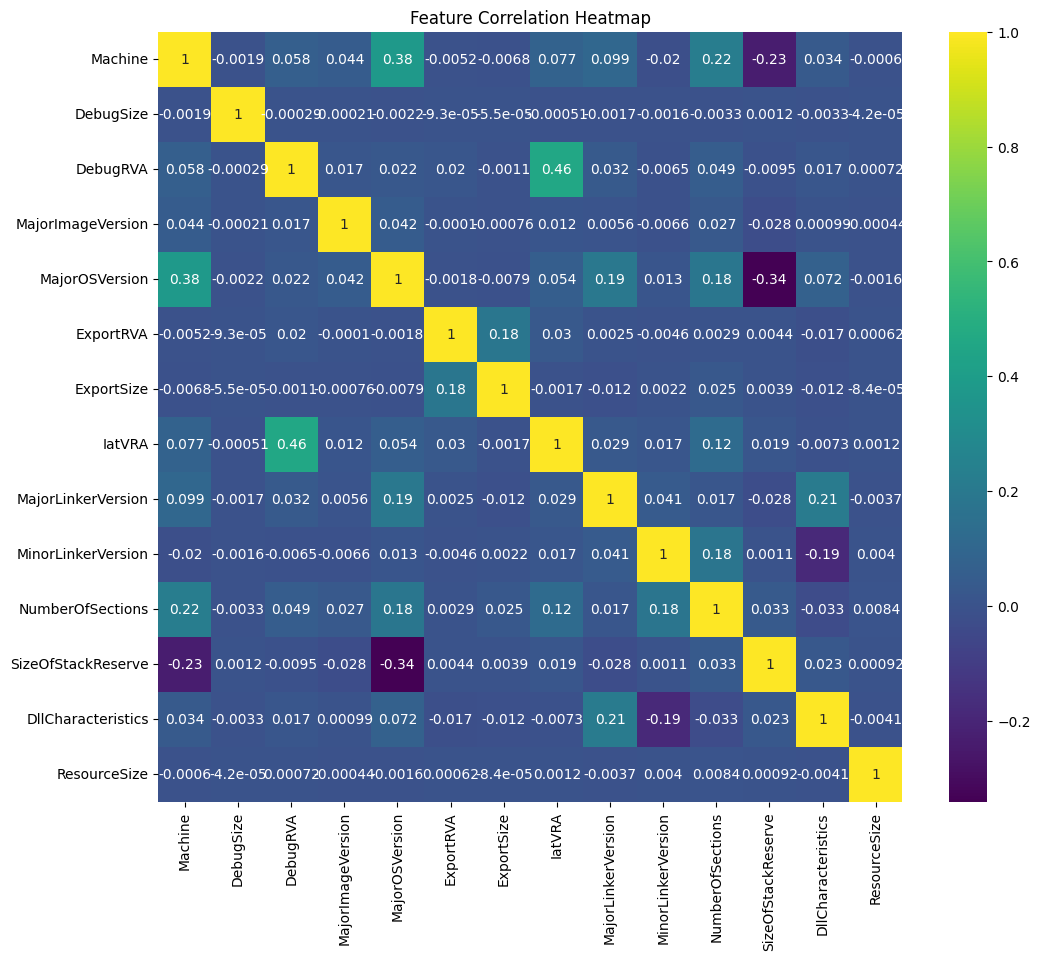

In [5]:
# Feature Correlation Analysis
plt.figure(figsize=(12, 10))
correlation_matrix = df.drop(['FileName', 'md5Hash', 'BitcoinAddresses', 'Benign'], axis=1).corr()
sns.heatmap(correlation_matrix, cmap='viridis', annot=True)
plt.title('Feature Correlation Heatmap')
plt.show()

# ==============================================================================
# Cell 3: Preprocessing and Model Training
# ==============================================================================
## Feature Selection & Splitting


In [7]:
# Feature Selection & Splitting
X = df.drop(['FileName', 'md5Hash', 'BitcoinAddresses', 'Benign'], axis=1)
y = df['Benign']
feat_columns = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Preprocessing Pipeline

In [8]:
scaler = StandardScaler()
pca = PCA(n_components=0.95, random_state=42)

## Fit and transform the training data

In [9]:
X_train_scaled = scaler.fit_transform(X_train)
X_train_pca = pca.fit_transform(X_train_scaled)
print(f"PCA selected {X_train_pca.shape[1]} components, retaining 95% variance.")

PCA selected 13 components, retaining 95% variance.


## Supervised Model Training (Random Forest)

In [10]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_pca, y_train)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_balanced, y_train_balanced)
print("Supervised (Random Forest) model trained.")

Supervised (Random Forest) model trained.


## Unsupervised Model Training (GMM)

In [11]:
print("Tuning and training GMM...")
components_range = range(2, 8)
bics = []
best_bic = np.inf
best_comp = 2
for n in components_range:
    gmm_temp = GaussianMixture(n_components=n, covariance_type='diag', reg_covar=1e-3, random_state=42)
    gmm_temp.fit(X_train_pca)
    bic = gmm_temp.bic(X_train_pca)
    bics.append(bic)
    if bic < best_bic:
        best_bic = bic
        best_comp = n

gmm_model = GaussianMixture(n_components=best_comp, covariance_type='diag', reg_covar=1e-3, random_state=42)
gmm_model.fit(X_train_pca)
print(f"Unsupervised (GMM) model trained with {best_comp} components.")
gmm_scores = gmm_model.score_samples(X_train_pca)
GMM_MIN_SCORE, GMM_MAX_SCORE = gmm_scores.min(), gmm_scores.max()


Tuning and training GMM...
Unsupervised (GMM) model trained with 7 components.


# ==============================================================================
# GMM Evaluation and Visualization
# ==============================================================================


In [12]:
print("\n--- GMM Native Clustering Metrics & Visualizations ---")
gmm_labels_train = gmm_model.predict(X_train_pca)

# Print Scores
print(f"Silhouette Score: {silhouette_score(X_train_pca, gmm_labels_train):.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_train_pca, gmm_labels_train):.3f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_score(X_train_pca, gmm_labels_train):.2f}")


--- GMM Native Clustering Metrics & Visualizations ---
Silhouette Score: 0.282
Davies-Bouldin Index: 2.264
Calinski-Harabasz Index: 3898.56


## Plot 1: BIC Score (Elbow Method)

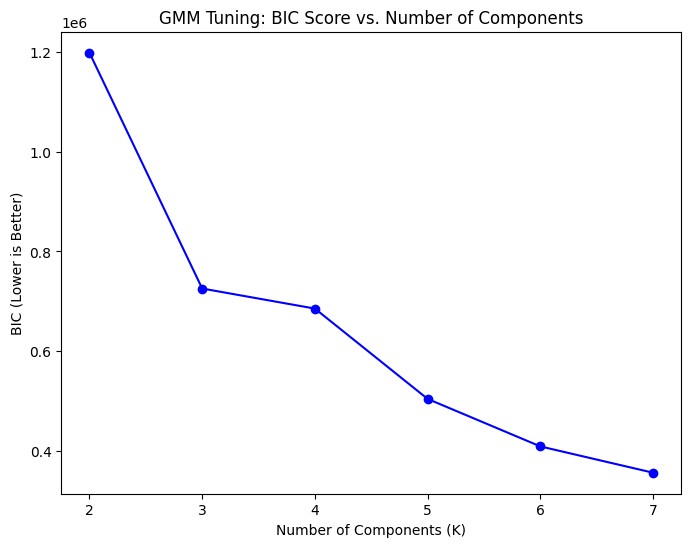

In [13]:
plt.figure(figsize=(8, 6))
plt.plot(components_range, bics, 'bo-')
plt.xlabel('Number of Components (K)')
plt.ylabel('BIC (Lower is Better)')
plt.title('GMM Tuning: BIC Score vs. Number of Components')
plt.show()

## Plot 2: Cluster Visualization (PCA)

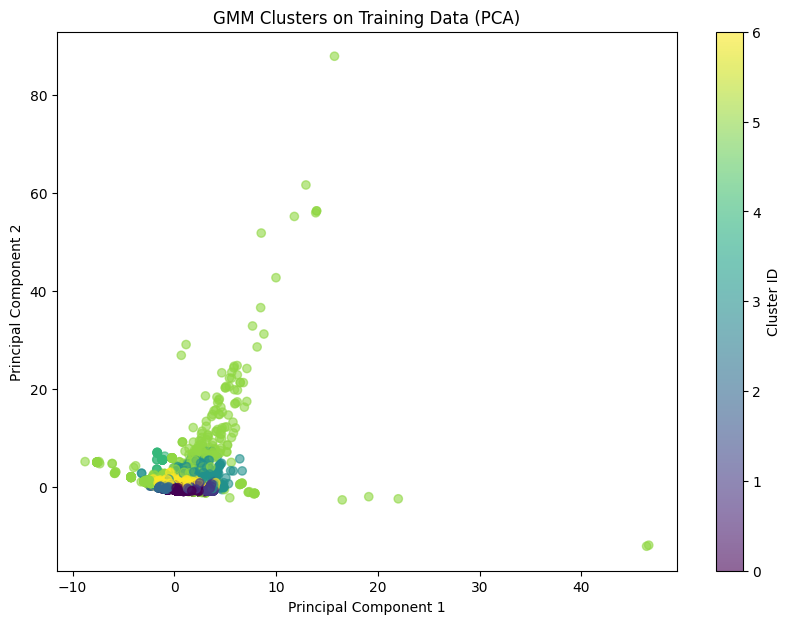

In [14]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=gmm_labels_train, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster ID')
plt.title('GMM Clusters on Training Data (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# ==============================================================================
# Final Model Evaluation
# ==============================================================================

In [15]:
def weighted_hybrid_predict(X_pca, rf_model, gmm_model, gmm_min, gmm_max, rf_weight=0.7):
    rf_proba_malware = rf_model.predict_proba(X_pca)[:, 0]
    gmm_log_likelihood = gmm_model.score_samples(X_pca)
    normalized_gmm_score = np.clip((gmm_log_likelihood - gmm_min) / (gmm_max - gmm_min), 0, 1)
    gmm_anomaly_score = 1 - normalized_gmm_score
    hybrid_score_malware = (rf_weight * rf_proba_malware) + ((1 - rf_weight) * gmm_anomaly_score)
    predictions = (hybrid_score_malware <= 0.5).astype(int)
    benign_confidence_score = 1 - hybrid_score_malware
    return predictions, benign_confidence_score

In [16]:
X_test_pca = pca.transform(scaler.transform(X_test))

## RF Only Evaluation

In [17]:
print("\n--- Random Forest Only Evaluation ---")
y_pred_rf = rf_model.predict(X_test_pca)
y_proba_rf = rf_model.predict_proba(X_test_pca)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}, Precision: {precision_score(y_test, y_pred_rf):.4f}, Recall: {recall_score(y_test, y_pred_rf):.4f}, F1: {f1_score(y_test, y_pred_rf):.4f}, ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")


--- Random Forest Only Evaluation ---
Accuracy: 0.9934, Precision: 0.9928, Recall: 0.9919, F1: 0.9923, ROC-AUC: 0.9989


# Hybrid Model Evaluation

In [18]:
print("\n--- Hybrid Model Evaluation ---")
y_pred_hybrid, y_proba_hybrid = weighted_hybrid_predict(X_test_pca, rf_model, gmm_model, GMM_MIN_SCORE, GMM_MAX_SCORE)
print(f"Accuracy: {accuracy_score(y_test, y_pred_hybrid):.4f}, Precision: {precision_score(y_test, y_pred_hybrid):.4f}, Recall: {recall_score(y_test, y_pred_hybrid):.4f}, F1: {f1_score(y_test, y_pred_hybrid):.4f}, ROC-AUC: {roc_auc_score(y_test, y_proba_hybrid):.4f}")


--- Hybrid Model Evaluation ---
Accuracy: 0.9923, Precision: 0.9881, Recall: 0.9943, F1: 0.9912, ROC-AUC: 0.9990


## Confusion Matrix

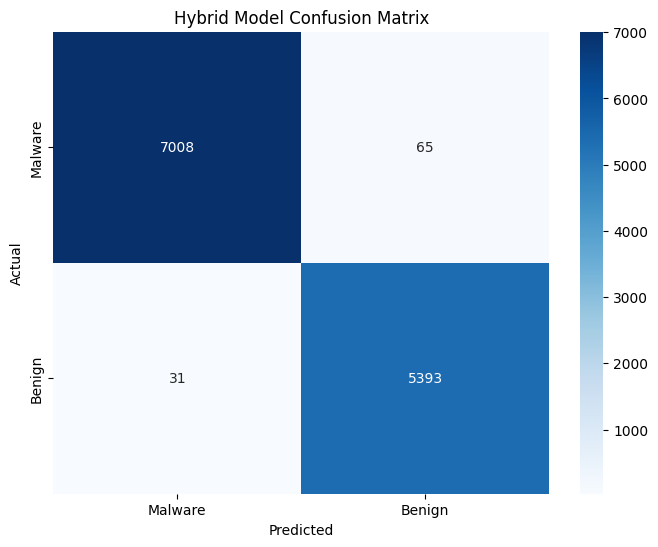

In [19]:
cm = confusion_matrix(y_test, y_pred_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Malware', 'Benign'], yticklabels=['Malware', 'Benign'])
plt.title('Hybrid Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## ROC Curve

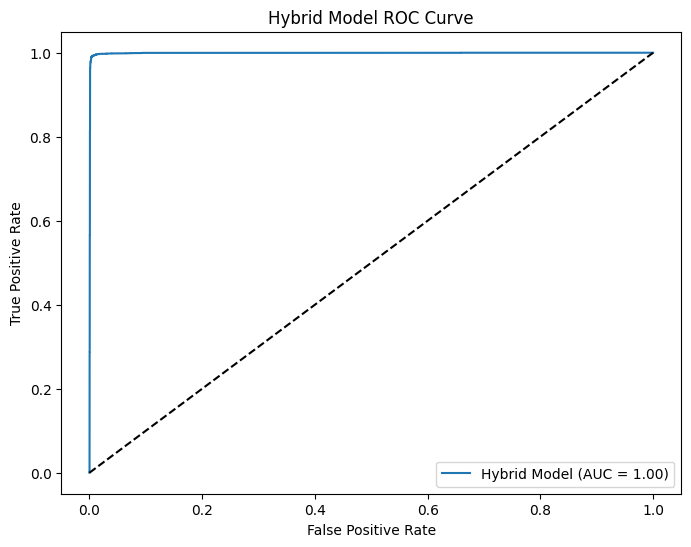

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_proba_hybrid)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Hybrid Model (AUC = {roc_auc_score(y_test, y_proba_hybrid):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Hybrid Model ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# ==============================================================================
# Model Saving
# ==============================================================================

In [21]:
model_dir = 'Hybrid_Model_V_Final'
os.makedirs(model_dir, exist_ok=True)
joblib.dump(rf_model, os.path.join(model_dir, 'rf_model.pkl'))
joblib.dump(gmm_model, os.path.join(model_dir, 'gmm_model.pkl'))
joblib.dump(scaler, os.path.join(model_dir, 'scaler.pkl'))
joblib.dump(pca, os.path.join(model_dir, 'pca.pkl'))
joblib.dump(feat_columns, os.path.join(model_dir, 'feat_columns.pkl'))
joblib.dump((GMM_MIN_SCORE, GMM_MAX_SCORE), os.path.join(model_dir, 'gmm_scores.pkl'))
print(f"\nAll models and preprocessors saved to '{model_dir}' directory.")


All models and preprocessors saved to 'Hybrid_Model_V_Final' directory.


# ==============================================================================
# Scanning Functions
# ==============================================================================

In [22]:
def extract_pe_features(file_path=None, data=None):
    try:
        pe = pefile.PE(file_path, data=data)
        return {
            'Machine': pe.FILE_HEADER.Machine,
            'NumberOfSections': pe.FILE_HEADER.NumberOfSections,
            'DebugSize': pe.OPTIONAL_HEADER.DATA_DIRECTORY[pefile.DIRECTORY_ENTRY['IMAGE_DIRECTORY_ENTRY_DEBUG']].Size,
            'DebugRVA': pe.OPTIONAL_HEADER.DATA_DIRECTORY[pefile.DIRECTORY_ENTRY['IMAGE_DIRECTORY_ENTRY_DEBUG']].VirtualAddress,
            'MajorImageVersion': pe.OPTIONAL_HEADER.MajorImageVersion,
            'MajorOSVersion': pe.OPTIONAL_HEADER.MajorOperatingSystemVersion,
            'ExportRVA': pe.OPTIONAL_HEADER.DATA_DIRECTORY[pefile.DIRECTORY_ENTRY['IMAGE_DIRECTORY_ENTRY_EXPORT']].VirtualAddress,
            'ExportSize': pe.OPTIONAL_HEADER.DATA_DIRECTORY[pefile.DIRECTORY_ENTRY['IMAGE_DIRECTORY_ENTRY_EXPORT']].Size,
            'IatVRA': pe.OPTIONAL_HEADER.DATA_DIRECTORY[pefile.DIRECTORY_ENTRY['IMAGE_DIRECTORY_ENTRY_IMPORT']].VirtualAddress,
            'MajorLinkerVersion': pe.OPTIONAL_HEADER.MajorLinkerVersion,
            'MinorLinkerVersion': pe.OPTIONAL_HEADER.MinorLinkerVersion,
            'SizeOfStackReserve': pe.OPTIONAL_HEADER.SizeOfStackReserve,
            'DllCharacteristics': pe.OPTIONAL_HEADER.DllCharacteristics,
            'ResourceSize': pe.OPTIONAL_HEADER.DATA_DIRECTORY[pefile.DIRECTORY_ENTRY['IMAGE_DIRECTORY_ENTRY_RESOURCE']].Size,
        }
    except Exception:
        return None

In [23]:
def get_prediction_details(file_data, models):
    features = extract_pe_features(data=file_data)
    if features is None:
        return "Error: Not a valid PE file or feature extraction failed."

    df = pd.DataFrame([features]).reindex(columns=models['feat_columns'], fill_value=0)
    
    X_scaled = models['scaler'].transform(df)
    X_pca = models['pca'].transform(X_scaled)
    
    prediction, benign_prob = weighted_hybrid_predict(
        X_pca, models['rf'], models['gmm'], 
        models['gmm_scores'][0], models['gmm_scores'][1]
    )
    
    result = "Benign" if prediction[0] == 1 else "Malware"
    malware_prob = 1 - benign_prob[0]
    
    return (f"Prediction: {result}\n\n" 
            f"Malware Confidence: {malware_prob:.2%}\n" 
            f"Benign Confidence: {benign_prob[0]:.2%}")

In [24]:
print("Scanning functions defined.")

Scanning functions defined.


# ==============================================================================
# GUI and Example Scans
## Note: This part is for demonstration. The GUI will not run inside most notebook
## environments but will run if you execute this file as a standalone script.
# ==============================================================================

In [25]:
class MalwareScannerApp(tk.Tk):
    def __init__(self, models):
        super().__init__()
        self.title("Hybrid Malware Scanner")
        self.geometry("500x400")
        self.models = models

        # URL Input
        tk.Label(self, text="Scan URL:").pack(pady=(10,0))
        self.url_entry = tk.Entry(self, width=60)
        self.url_entry.pack(padx=10, pady=5)
        tk.Button(self, text="Scan URL", command=self.scan_url).pack()

        # File Upload
        tk.Label(self, text="OR").pack(pady=10)
        tk.Button(self, text="Upload and Scan Local File", command=self.scan_local_file).pack()

        # Results Display
        tk.Label(self, text="--- Results ---").pack(pady=(20,0))
        self.result_text = tk.Text(self, height=8, width=60, state='disabled')
        self.result_text.pack(pady=10, padx=10)

    def display_result(self, result_str):
        self.result_text.config(state='normal')
        self.result_text.delete('1.0', tk.END)
        self.result_text.insert(tk.END, result_str)
        self.result_text.config(state='disabled')

    def scan_url(self):
        url = self.url_entry.get()
        if not url:
            messagebox.showwarning("Input Error", "Please enter a URL.")
            return
        
        self.display_result(f"Scanning URL: {url}\nPlease wait...")
        self.update_idletasks()

        try:
            response = requests.get(url, timeout=15)
            response.raise_for_status()
            result = get_prediction_details(response.content, self.models)
        except requests.exceptions.RequestException as e:
            result = f"URL Scan Error: {e}\n(Note: GitHub often blocks frequent requests with a 429 error.)"
        
        self.display_result(result)

    def scan_local_file(self):
        file_path = filedialog.askopenfilename(
            title="Select a file to scan",
            filetypes=(("Executable files", "*.exe *.dll"), ("All files", "*.*" ))
        )
        if not file_path:
            return

        self.display_result(f"Scanning file: {os.path.basename(file_path)}\nPlease wait...")
        self.update_idletasks()

        try:
            with open(file_path, "rb") as f:
                file_data = f.read()
            result = get_prediction_details(file_data, self.models)
        except Exception as e:
            result = f"Local File Scan Error: {e}"

        self.display_result(result)

# --- Main Execution Block ---
# The following code will only run if the script is executed directly
if __name__ == "__main__":
    model_dir = 'Hybrid_Model_V_Final'
    
    # Step 1: Train models if they don't exist
    if not os.path.exists(model_dir):
        print("No pre-trained models found. Running training pipeline...")
        train_and_evaluate()
    
    # Step 2: Load the models for the GUI
    try:
        print(f"--- Loading Models from '{model_dir}' for GUI ---")
        loaded_models = {
            'rf': joblib.load(os.path.join(model_dir, 'rf_model.pkl')),
            'gmm': joblib.load(os.path.join(model_dir, 'gmm_model.pkl')),
            'scaler': joblib.load(os.path.join(model_dir, 'scaler.pkl')),
            'pca': joblib.load(os.path.join(model_dir, 'pca.pkl')),
            'feat_columns': joblib.load(os.path.join(model_dir, 'feat_columns.pkl')),
            'gmm_scores': joblib.load(os.path.join(model_dir, 'gmm_scores.pkl'))
        }
        print("Models loaded successfully.")
        
        # Step 3: Launch the GUI
        app = MalwareScannerApp(loaded_models)
        app.mainloop()

    except FileNotFoundError:
        print(f"Error: Could not load models from '{model_dir}'. Please run the training process first.")

--- Loading Models from 'Hybrid_Model_V_Final' for GUI ---
Models loaded successfully.
